Accuracy: 70.18%


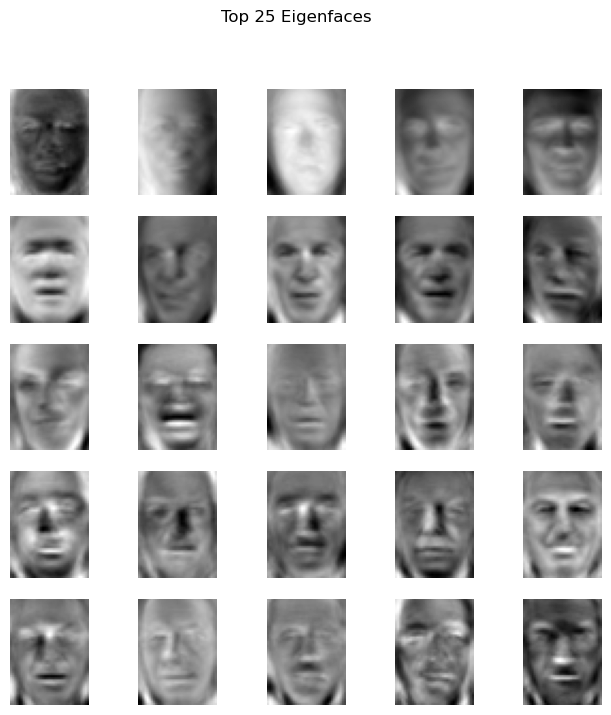

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load dataset
faces = fetch_lfw_people(min_faces_per_person=100, resize=0.4)
X = faces.images.reshape((faces.images.shape[0], -1))  # Flatten images
y = faces.target  # Labels

# Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Apply PCA for dimensionality reduction
n_components = 100  # Number of principal components
pca = PCA(n_components=n_components, whiten=True, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Train a KNN classifier
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn.fit(X_train_pca, y_train)

# Predict on test set
y_pred = knn.predict(X_test_pca)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

# Plot some Eigenfaces
eigenfaces = pca.components_.reshape((n_components, faces.images.shape[1], faces.images.shape[2]))
fig, axes = plt.subplots(5, 5, figsize=(8, 8))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(eigenfaces[i], cmap='gray')
    ax.axis('off')
plt.suptitle('Top 25 Eigenfaces')
plt.show()


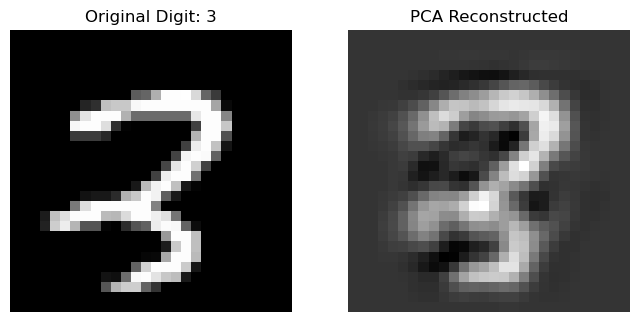

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
import random

# Load MNIST dataset
X, y = fetch_openml('mnist_784', version=1, as_frame=False, return_X_y=True)
X = X / 255.0  # Normalize pixel values

# PCA using SVD
X_mean = np.mean(X, axis=0)
X_centered = X - X_mean
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

n_components = 50  # Number of principal components
X_pca = X_centered @ Vt[:n_components].T  # Transform data to PCA space
X_reconstructed = X_pca @ Vt[:n_components] + X_mean  # Reconstruct the image

# Select a random digit
idx = random.randint(0, len(X) - 1)

# Plot the original and PCA-reconstructed images
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(X[idx].reshape(28, 28), cmap='gray')
plt.title(f'Original Digit: {y[idx]}')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(X_reconstructed[idx].reshape(28, 28), cmap='gray')
plt.title('PCA Reconstructed')
plt.axis('off')

plt.show()


Accuracy: 61.40%


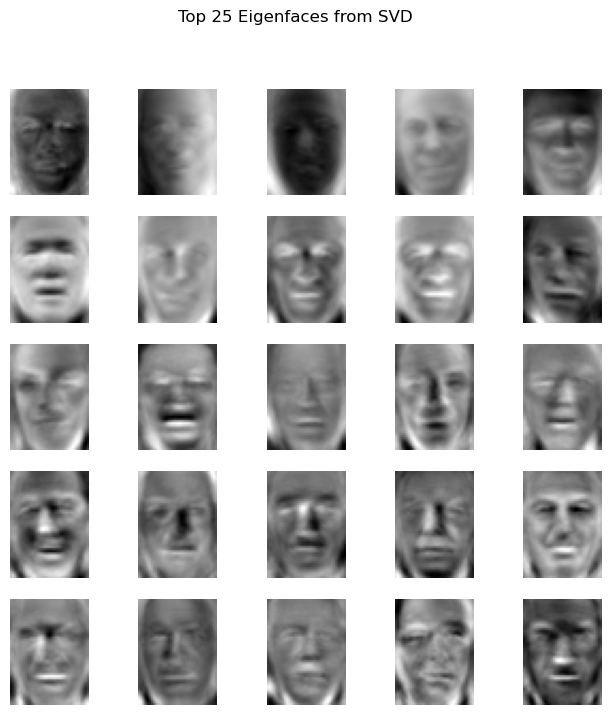

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load dataset
faces = fetch_lfw_people(min_faces_per_person=100, resize=0.4)
X = faces.images.reshape((faces.images.shape[0], -1))  # Flatten images
y = faces.target  # Labels

# Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Center the data by subtracting the mean
X_train_mean = X_train - np.mean(X_train, axis=0)
X_test_mean = X_test - np.mean(X_test, axis=0)

# Perform SVD on the training data
U, S, Vt = np.linalg.svd(X_train_mean, full_matrices=False)

# Choose the number of components (e.g., 100)
n_components = 100

# Project the data onto the first 'n_components' singular vectors (U[:, :n_components])
X_train_svd = np.dot(X_train_mean, Vt.T[:, :n_components])
X_test_svd = np.dot(X_test_mean, Vt.T[:, :n_components])

# Train a KNN classifier
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn.fit(X_train_svd, y_train)

# Predict on test set
y_pred = knn.predict(X_test_svd)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

# Plot some Eigenfaces (top components from Vt)
eigenfaces = Vt[:n_components].reshape((n_components, faces.images.shape[1], faces.images.shape[2]))
fig, axes = plt.subplots(5, 5, figsize=(8, 8))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(eigenfaces[i], cmap='gray')
    ax.axis('off')
plt.suptitle('Top 25 Eigenfaces from SVD')
plt.show()


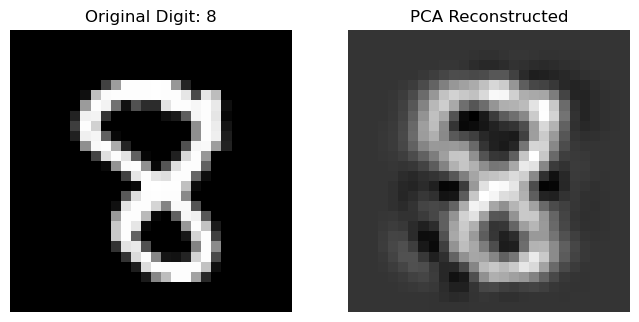

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
import random

# Load MNIST dataset
X, y = fetch_openml('mnist_784', version=1, as_frame=False, return_X_y=True)
X = X / 255.0  # Normalize pixel values

# PCA using sklearn.decomposition.PCA
n_components = 50  # Number of principal components
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X)  # Perform PCA
X_reconstructed = pca.inverse_transform(X_pca)  # Reconstruct the image

# Select a random digit
idx = random.randint(0, len(X) - 1)

# Plot the original and PCA-reconstructed images
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(X[idx].reshape(28, 28), cmap='gray')
plt.title(f'Original Digit: {y[idx]}')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(X_reconstructed[idx].reshape(28, 28), cmap='gray')
plt.title('PCA Reconstructed')
plt.axis('off')

plt.show()
